# Task 4 – Sentiment Analysis

## Objective

Build a machine learning model that classifies movie reviews as positive or negative.

### Models Used
- Multinomial Naive Bayes
- Logistic Regression

### Techniques Used
- Text preprocessing
- Stopword removal
- Tokenization
- TF-IDF Vectorization
- Train-Test Split
- Model Training
- Model Evaluation
- Confusion Matrix
- WordCloud Visualization
- Error Analysis

### Import Libraries

In [1]:
!pip install wordcloud

In [2]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [3]:
#Download NLTK Resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Load the Dataset

In [4]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### Inspect Dataset

In [5]:
df.shape

(50000, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [7]:
df.describe(include="all")

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [8]:
df.columns

Index(['review', 'sentiment'], dtype='object')

### Check Missing Values

In [9]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

### Remove Duplicate Reviews

In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 418


In [11]:
df = df.drop_duplicates()

In [12]:
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (49582, 2)


### Check Sentiment Distribution

In [13]:
print(df["sentiment"].value_counts())

sentiment
positive    24884
negative    24698
Name: count, dtype: int64


### Sentiment Distribution Visualization

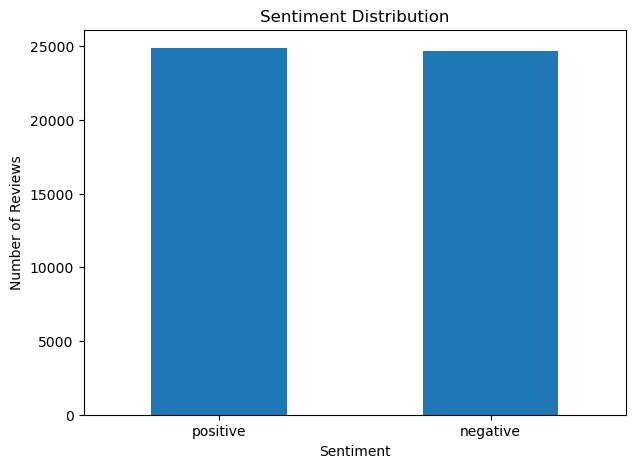

In [14]:
plt.figure(figsize=(7, 5))

df["sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.show()

### Convert Sentiment to Numeric

In [15]:
df["sentiment_label"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

df.head()

,review,sentiment,sentiment_label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


### Text Preprocessing

#### Preprocessing pipeline will perform:

Lowercase conversion

Remove HTML tags

Remove punctuation

Remove numbers

Tokenization

Stopword removal

Remove very short words


In [16]:
#Create Stopword List
stop_words = set(stopwords.words("english"))

### Text Cleaning Function

In [17]:
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)
    
    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    # Remove numbers
    text = re.sub(r"\d+", " ", text)
    
    # Tokenization
    words = word_tokenize(text)
    
    # Remove stopwords and very short words
    words = [
        word for word in words
        if word not in stop_words and len(word) > 2
    ]
    
    return " ".join(words)

### Apply Text Cleaning

In [18]:
df["cleaned_review"] = df["review"].apply(clean_text)

In [19]:
df[["review", "cleaned_review"]].head()

,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching episode youll...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


### Explanation of Preprocessing

#### Text Preprocessing

Text preprocessing converts raw reviews into a clean format suitable for machine learning.

The following steps were performed:

1. **Lowercasing** – Converts all text into lowercase so that words such as "Movie" and "movie" are treated similarly.

2. **HTML Removal** – Removes HTML tags that may occur in online reviews.

3. **Punctuation Removal** – Removes punctuation marks that generally do not provide useful information for the basic classification model.

4. **Number Removal** – Removes numerical characters that are not important for this sentiment classification task.

5. **Tokenization** – Splits the review into individual words.

6. **Stopword Removal** – Removes common words such as "the", "is", "and", and "was" that usually contribute little to the classification.

7. **Short Word Removal** – Removes very short tokens to reduce noise.

The cleaned text is then converted into numerical features using TF-IDF.

In [20]:
df.head()

,review,sentiment,sentiment_label,cleaned_review
0,One of the other reviewers has mentioned that ...,positive,1,one reviewers mentioned watching episode youll...
1,A wonderful little production. <br /><br />The...,positive,1,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,1,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,0,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1,petter matteis love time money visually stunni...


In [21]:
print(df[["review", "cleaned_review", "sentiment"]].head())

                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                      cleaned_review sentiment  
0  one reviewers mentioned watching episode youll...  positive  
1  wonderful little production filming technique ...  positive  
2  thought wonderful way spend time hot summer we...  positive  
3  basically theres family little boy jake thinks...  negative  
4  petter matteis love time money visually stunni...  positive  


### TF-IDF Explanation
#### TF-IDF Vectorization

TF-IDF (Term Frequency-Inverse Document Frequency) converts text documents into numerical feature vectors.

It assigns higher importance to words that are frequent in a particular document but relatively uncommon across the entire dataset.

TF-IDF is useful for sentiment analysis because words that are strongly associated with positive or negative opinions can receive meaningful feature weights.

The vectorizer is configured with unigrams and bigrams so that both individual words and short phrases can contribute to sentiment classification.


### Separate X and y

In [22]:
X = df["cleaned_review"]
y = df["sentiment_label"]

### Train/Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [24]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 39665
Testing samples: 9917


### TF-IDF Vectorizer

In [25]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

In [26]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [27]:
X_test_tfidf = tfidf.transform(X_test)

In [28]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (39665, 50000)
Testing TF-IDF shape: (9917, 50000)


### Model 1 — Multinomial Naive Bayes

In [29]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [30]:
#Make Predictions
y_pred_nb = nb_model.predict(X_test_tfidf)

### Evaluate Naive Bayes

In [31]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("Naive Bayes Results")
print("-------------------")
print("Accuracy :", accuracy_nb)
print("Precision:", precision_nb)
print("Recall   :", recall_nb)
print("F1 Score :", f1_nb)

Naive Bayes Results
-------------------
Accuracy : 0.8843400221841282
Precision: 0.8802621127879269
Recall   : 0.8906972071529033
F1 Score : 0.8854489164086687


### Classification Report

In [32]:
print(classification_report(
    y_test,
    y_pred_nb,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.89      0.88      0.88      4940
    Positive       0.88      0.89      0.89      4977

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



### Naive Bayes Confusion Matrix

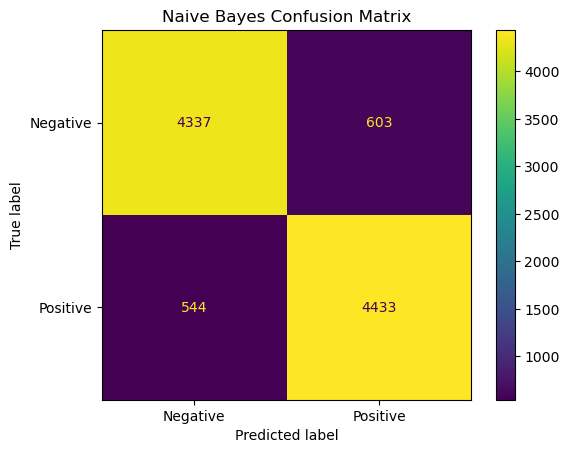

In [33]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["Negative", "Positive"]
)

disp.plot()

plt.title("Naive Bayes Confusion Matrix")
plt.show()

### Model 2 — Logistic Regression

In [34]:
#Train Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [35]:
#Predictions
y_pred_lr = lr_model.predict(X_test_tfidf)

In [36]:
#Evaluate Logistic Regression
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1 Score :", f1_lr)

Logistic Regression Results
---------------------------
Accuracy : 0.899263890289402
Precision: 0.8912273800157356
Recall   : 0.9103877838055053
F1 Score : 0.9007056952589206


In [37]:
#Classification Report
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      4940
    Positive       0.89      0.91      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



### Logistic Regression Confusion Matrix

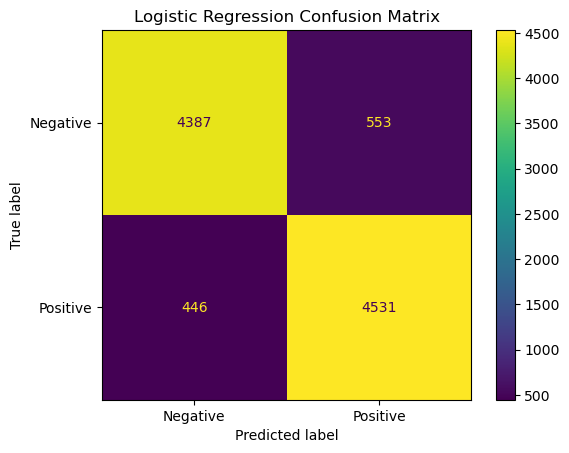

In [38]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Negative", "Positive"]
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Compare Both Models

In [39]:
results = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [
        accuracy_nb,
        accuracy_lr
    ],
    "Precision": [
        precision_nb,
        precision_lr
    ],
    "Recall": [
        recall_nb,
        recall_lr
    ],
    "F1 Score": [
        f1_nb,
        f1_lr
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.884340,0.880262,0.890697,0.885449
1,Logistic Regression,0.899264,0.891227,0.910388,0.900706


### Model Comparison Chart

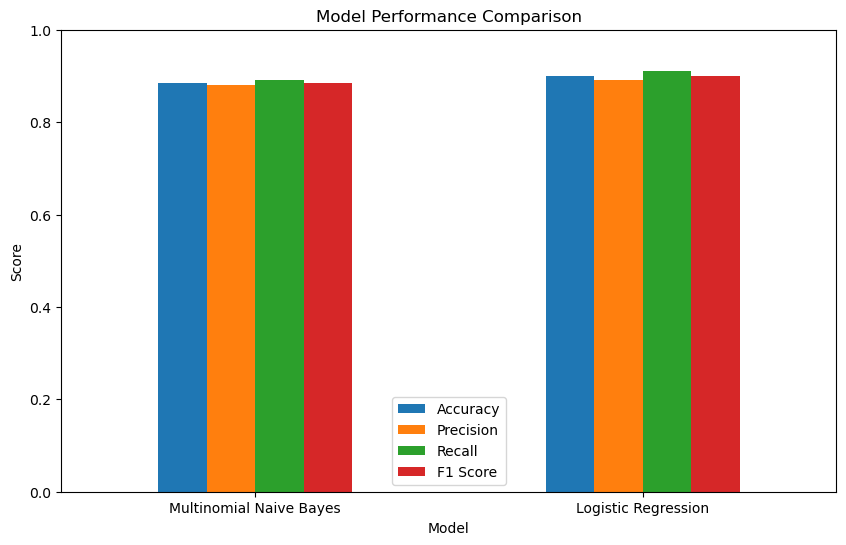

In [40]:
results.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]].plot(kind="bar", figsize=(10, 6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()

### WordCloud — Positive Reviews

In [41]:
positive_text = " ".join(
    df[df["sentiment"] == "positive"]["cleaned_review"]
)

In [42]:
positive_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(positive_text)

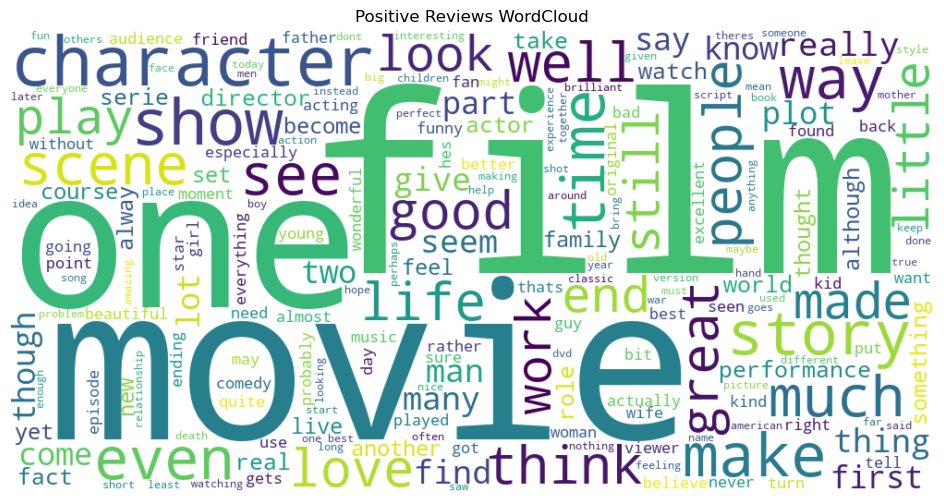

In [43]:
plt.figure(figsize=(12, 6))

plt.imshow(positive_wordcloud, interpolation="bilinear")

plt.axis("off")
plt.title("Positive Reviews WordCloud")

plt.show()

### WordCloud — Negative Reviews

In [44]:
negative_text = " ".join(
    df[df["sentiment"] == "negative"]["cleaned_review"]
)

In [45]:
negative_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(negative_text)

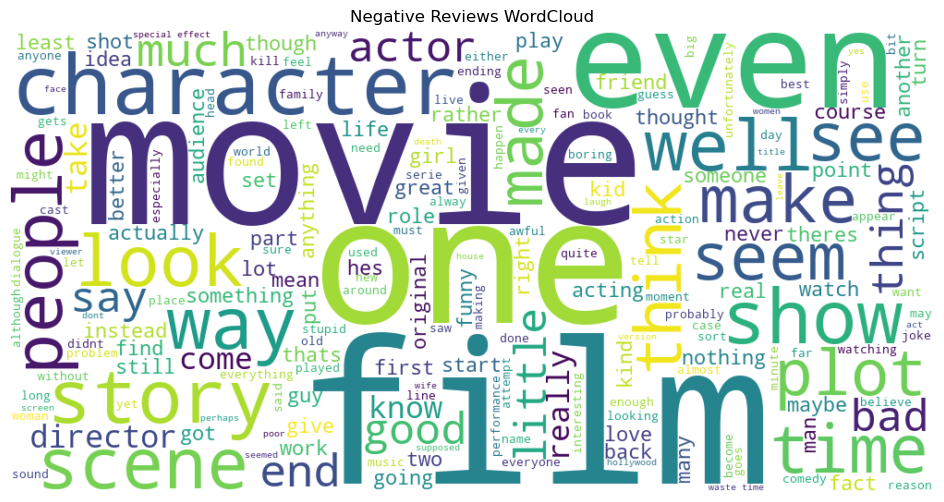

In [46]:
plt.figure(figsize=(12, 6))

plt.imshow(negative_wordcloud, interpolation="bilinear")

plt.axis("off")
plt.title("Negative Reviews WordCloud")

plt.show()

### Misclassified Reviews

In [47]:
error_df = pd.DataFrame({
    "review": X_test,
    "actual": y_test,
    "predicted": y_pred_lr
})

In [48]:
misclassified = error_df[
    error_df["actual"] != error_df["predicted"]
]

In [49]:
print("Number of misclassified reviews:", len(misclassified))

Number of misclassified reviews: 999


### Display 5 Misclassified Examples

In [50]:
for i, row in misclassified.head(5).iterrows():
    print("=" * 100)
    print("Review:")
    print(row["review"])
    print()
    print("Actual Sentiment:",
          "Positive" if row["actual"] == 1 else "Negative")
    print("Predicted Sentiment:",
          "Positive" if row["predicted"] == 1 else "Negative")
    print()

Review:
isnt exactly great film admire writers director trying something little different films main theme fate small seemingly insignificant things greatly change future ways reminds film sliding doors though instead focusing one random event seemingly random stuff happens repeatedly one helps build cute conclusion plus odd bald guy seems understand talks one brief scenelike hes sort omnipotent theres absolutely explanation film like two guys fight clock tower hudsucker proxy dvd jacket shows audrey tautou capitalize success amelie though one many actors film one starring role pace brisk acting fine conclusion isnt bad reason didnt score higher characters bit uninteresting think movie could perhaps tightened less subplots

Actual Sentiment: Positive
Predicted Sentiment: Negative

Review:
despite huge fan fred astaire ginger rogers movies wasnt years ago first saw follow fleet knew songs old astairerogers record yes vinyl knew nothing plot unfortunately songs catchy ginger rogers chara

### Error Analysis

Some reviews are difficult for the model to classify correctly.

Possible reasons for misclassification include:

1. **Sarcasm**
   - A review may use positive words sarcastically to express a negative opinion.

2. **Mixed Sentiment**
   - A review may contain both positive and negative opinions.

3. **Context Dependence**
   - The meaning of a sentence may depend on the surrounding context.

4. **Negation**
   - Phrases such as "not good" can be difficult because the word "good" is normally associated with positive sentiment.

5. **Complex Language**
   - Long reviews can contain many opinions, making the overall sentiment difficult to determine.

6. **Vocabulary Limitations**
   - The model may encounter words or phrases that were not sufficiently represented during training.

### Optional — Checking Prediction on Own Reviews

In [51]:
def predict_sentiment(review):
    cleaned = clean_text(review)
    vector = tfidf.transform([cleaned])
    prediction = lr_model.predict(vector)[0]
    
    if prediction == 1:
        return "Positive"
    else:
        return "Negative"

In [52]:
predict_sentiment(
    "This movie was fantastic, emotional and extremely enjoyable."
)

'Positive'

In [53]:
predict_sentiment(
    "The movie was boring, disappointing and a complete waste of time."
)

'Negative'

### Model Performance

In [54]:
best_model = results.loc[
    results["F1 Score"].idxmax(),
    "Model"
]

best_model

'Logistic Regression'

# Conclusion

In this project, a sentiment analysis system was developed to classify IMDb movie reviews into positive and negative categories.

The text data was cleaned using lowercase conversion, HTML removal, punctuation removal, tokenization and stopword removal.

TF-IDF vectorization was then used to convert the cleaned text into numerical features.

Two machine learning algorithms were trained:

- Multinomial Naive Bayes
- Logistic Regression

Both models were evaluated using accuracy, precision, recall and F1-score along with confusion matrices.

Based on the evaluation results, the model with the highest F1-score was selected as the best-performing model.

The model can be useful for automatically analyzing large volumes of customer feedback, movie reviews, product reviews and social media opinions.

However, errors can occur when the text contains sarcasm, mixed sentiment, negation, complex language or context-dependent meanings.

Overall, this project demonstrates how Natural Language Processing and machine learning can be used to automatically classify text sentiment.

### Real-World Applications

Sentiment analysis can be used in many real-world applications:

- Customer feedback analysis
- Product review analysis
- Social media monitoring
- Brand reputation monitoring
- Movie and entertainment reviews
- Customer support analysis
- E-commerce review analysis
- Market research
- Survey response analysis

For example, an e-commerce company could automatically analyze thousands of customer reviews and identify whether customers are generally satisfied or dissatisfied with a product.